In [59]:
import os
os.getcwd()  #check the directory

#Readme
##https://www.kaggle.com/datasets/ankam6010/synthetic-hr-burnout-dataset

'/Users/sharonraj/Desktop/DTSC610/project data options'

In [60]:
os.chdir('/Users/sharonraj/Desktop/DTSC610/project data options') #change directory

In [61]:
import pandas as pd   #load csv file and view first 5 rows
df=pd.read_csv("synthetic_employee_burnout.csv")
print(df.head())

          Name  Age  Gender   JobRole  Experience  WorkHoursPerWeek  \
0   Max Ivanov   32    Male   Analyst           3                60   
1     Max Wang   40  Female  Engineer           9                47   
2  Nina Petrov   33  Female  Engineer           2                44   
3  John Ivanov   35  Female   Manager           6                44   
4    John Wang   59    Male     Sales           8                38   

   RemoteRatio  SatisfactionLevel  StressLevel  Burnout  
0           21               4.40            1        0  
1           67               2.09            2        0  
2           20               2.58            3        0  
3           70               3.23            8        0  
4           46               4.41            1        0  


In [62]:
print("Number of observations:",df.shape[0])       #number of rows
print("Number of variables:",df.shape[1])          #number of columns

Number of observations: 2000
Number of variables: 10


In [63]:
print("Names of variables:", df.columns)        #column names
print("Types of data:", df.dtypes)              #types of data
## each row represents the employee data set for listed columns or variables

Names of variables: Index(['Name', 'Age', 'Gender', 'JobRole', 'Experience', 'WorkHoursPerWeek',
       'RemoteRatio', 'SatisfactionLevel', 'StressLevel', 'Burnout'],
      dtype='object')
Types of data: Name                  object
Age                    int64
Gender                object
JobRole               object
Experience             int64
WorkHoursPerWeek       int64
RemoteRatio            int64
SatisfactionLevel    float64
StressLevel            int64
Burnout                int64
dtype: object


In [64]:
print("Missing values in variables:", df.isnull().sum())      #check for missing variables

dupes=df.duplicated().sum()                                   #define dupes to check for duplicate and print them
print("number of duplicates are:", dupes)

print("Summary of numerical variables:")                      #summary of numerical variables
print(df.describe()) 

for col in df.select_dtypes(include="object"):                #check categorical variables, check for unique items in all columns, print the column name and unique items in their respective columns
    print(col)
    print(df[col].unique())

#cleaning was not required since there were no missing values, no duplicates in the observed outputs. Some columns like names, gender, job role have duplciates but they dont require cleaning since they do not influence or duplciate another employee but unique to the employee's profile

Missing values in variables: Name                 0
Age                  0
Gender               0
JobRole              0
Experience           0
WorkHoursPerWeek     0
RemoteRatio          0
SatisfactionLevel    0
StressLevel          0
Burnout              0
dtype: int64
number of duplicates are: 0
Summary of numerical variables:
               Age   Experience  WorkHoursPerWeek  RemoteRatio  \
count  2000.000000  2000.000000       2000.000000  2000.000000   
mean     40.694500    10.074500         49.588000    49.973000   
std      11.286756     9.148267         11.832424    29.151298   
min      22.000000     0.000000         30.000000     0.000000   
25%      31.000000     3.000000         39.000000    24.000000   
50%      41.000000     7.000000         49.000000    49.000000   
75%      50.000000    15.000000         60.000000    75.000000   
max      60.000000    39.000000         70.000000   100.000000   

       SatisfactionLevel  StressLevel      Burnout  
count        2000.00

In [65]:
num_variables=df.select_dtypes(include=["int64","float64"])      #numberical variables defined
cat_variables=df.select_dtypes(include=["object"])             #categorical varibales defined

num_summary=num_variables.describe().T
print("Numerical Variable Summary:", num_summary)               #we can see the burnout mean is 0.0645, which is 6.45% employees face burnout

for col in cat_variables.columns:
    frequency=df[col].value_counts()
    percent=df[col].value_counts(normalize=True)*100

cat_summary=pd.DataFrame({
    "Freq": frequency,
    "Percent": percent.round(3)
})
print("Categorical Variable Summary:")                           #we see the percentage for all job roles are in an almost equal range ~20
print(cat_summary)


Numerical Variable Summary:                     count      mean        std   min   25%     50%   75%  \
Age                2000.0  40.69450  11.286756  22.0  31.0  41.000  50.0   
Experience         2000.0  10.07450   9.148267   0.0   3.0   7.000  15.0   
WorkHoursPerWeek   2000.0  49.58800  11.832424  30.0  39.0  49.000  60.0   
RemoteRatio        2000.0  49.97300  29.151298   0.0  24.0  49.000  75.0   
SatisfactionLevel  2000.0   2.99523   1.155431   1.0   2.0   3.025   4.0   
StressLevel        2000.0   5.43200   2.880890   1.0   3.0   5.000   8.0   
Burnout            2000.0   0.06450   0.245703   0.0   0.0   0.000   0.0   

                     max  
Age                 60.0  
Experience          39.0  
WorkHoursPerWeek    70.0  
RemoteRatio        100.0  
SatisfactionLevel    5.0  
StressLevel         10.0  
Burnout              1.0  
Categorical Variable Summary:
          Freq  Percent
JobRole                
Manager    419    20.95
Analyst    413    20.65
Sales      391    19.

In [66]:
burnout_freq=df["Burnout"].value_counts()
burnout_percent=df["Burnout"].value_counts(normalize=True)*100
burnout_summary=pd.DataFrame({
    "Freq":burnout_freq,
    "Percent":burnout_percent.round(2)
})
print("Distribution of Burnout Variable:",burnout_summary)

Distribution of Burnout Variable:          Freq  Percent
Burnout               
0        1871    93.55
1         129     6.45


In [67]:
major_percent=burnout_percent.max()
minor_percent=burnout_percent.min()

if (minor_percent<40):
    print(" The burnout class is imbalanced")
else:
    print("The burnout class is balanced")


 The burnout class is imbalanced


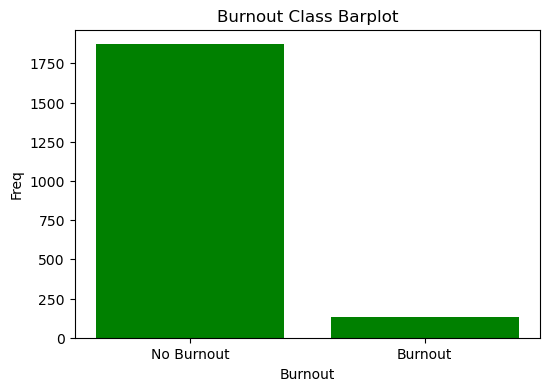

In [68]:
import matplotlib.pyplot as plt

burnout_counts=df["Burnout"].value_counts().sort_index()
label=["No Burnout","Burnout"]
plt.figure(figsize=(6,4))
plt.bar(label,burnout_counts, color="Green")
plt.title("Burnout Class Barplot")
plt.xlabel("Burnout")
plt.ylabel("Freq")
plt.show()


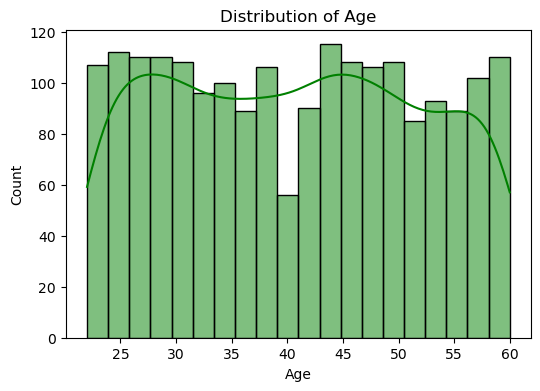

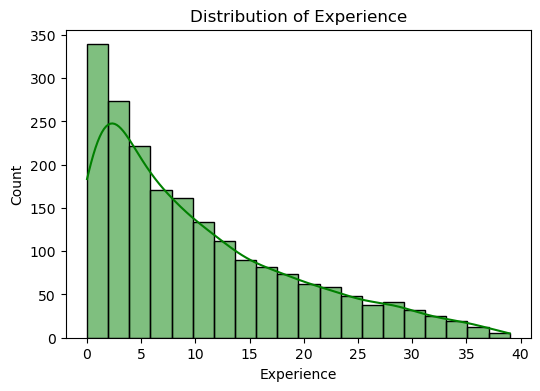

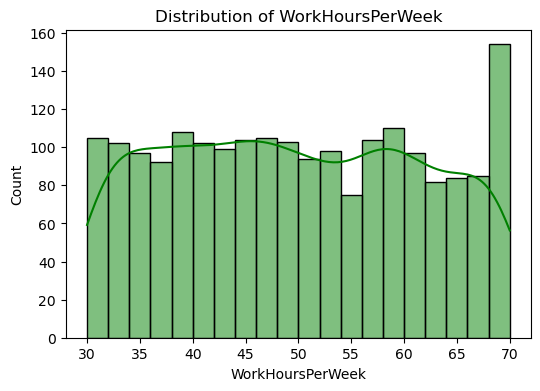

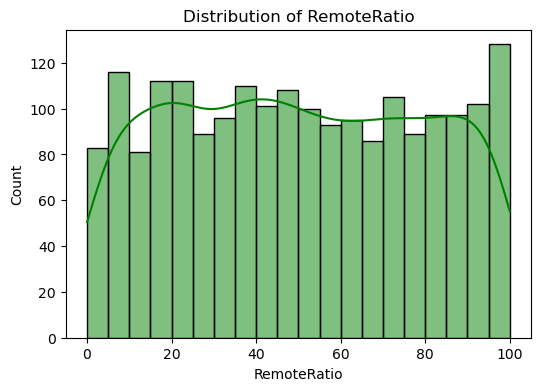

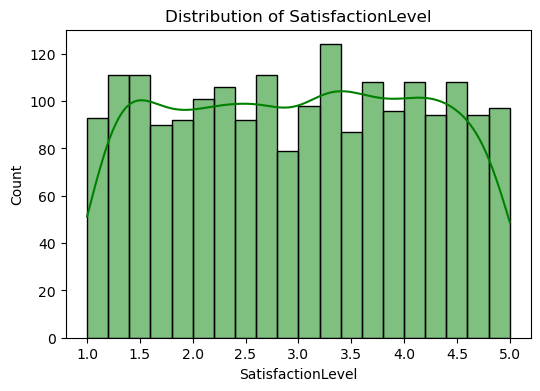

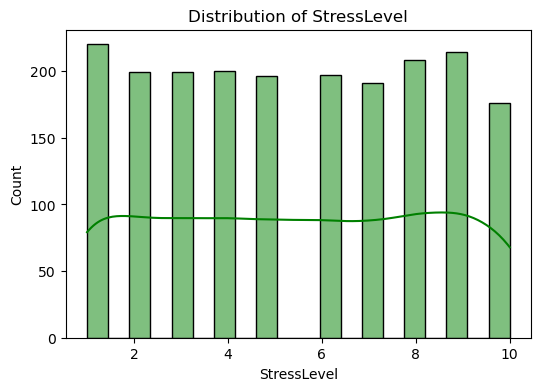

In [69]:
import seaborn as sns
numeric_vars = [
    "Age",
    "Experience",
    "WorkHoursPerWeek",
    "RemoteRatio",
    "SatisfactionLevel",
    "StressLevel"
]
for var in numeric_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], bins=20, kde=True, color="Green")
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Count")    
    plt.show()
    

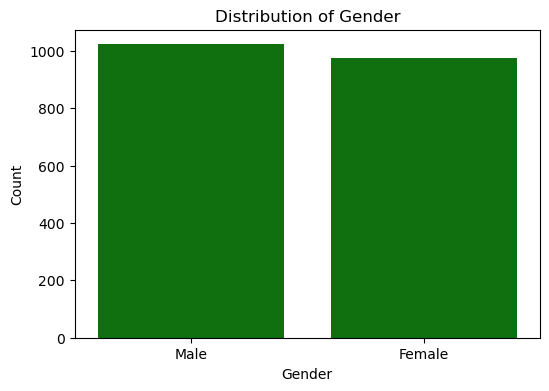

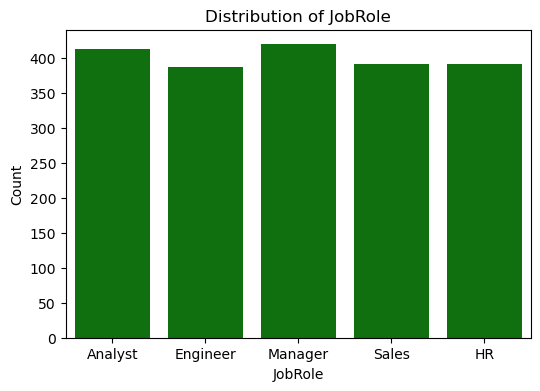

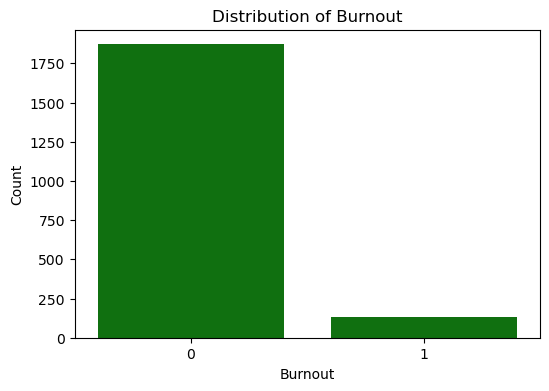

In [70]:
##Age: The age distribution is fairly uniform across employees aged **22–60**, with a slight concentration around the early 40s.
##Experience: Most employees have relatively low to moderate years of experience, while fewer employees have very high experience.The distribution is positively (right) skewed.
##WorkHoursPerWeek: Weekly working hours are spread fairly evenly between 30 and 70, mostly work approximately 45–55 hours per week.
##RemoteRatio: Remote work percentages are distributed across the full range **(0–100%)**
##SatisfactionLevel:Satisfaction scores are approximately evenly distributed between **1 and 5**, suggesting employees exhibit a wide range of job satisfaction levels.
##StressLevel: Extremely low and extremely high stress levels occur less frequently.


categoric_vars = ["Gender", "JobRole", "Burnout"]

for var in categoric_vars:

    plt.figure(figsize=(6,4))

    sns.countplot(x=var, data=df, color="Green")

    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.show()

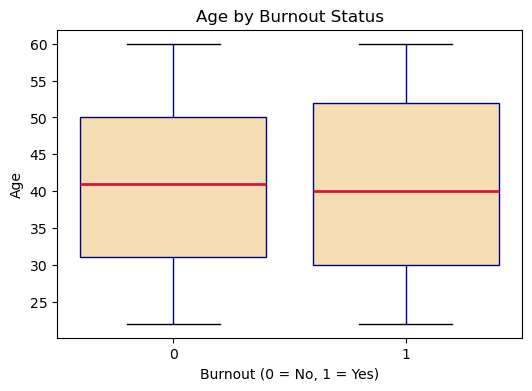

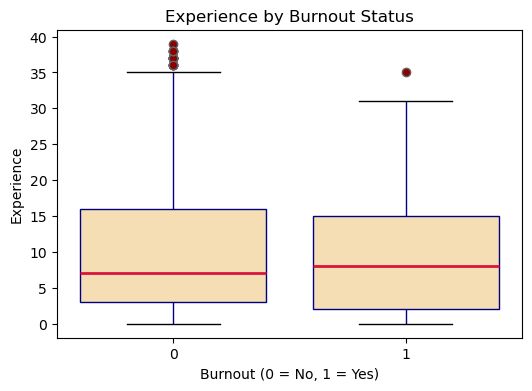

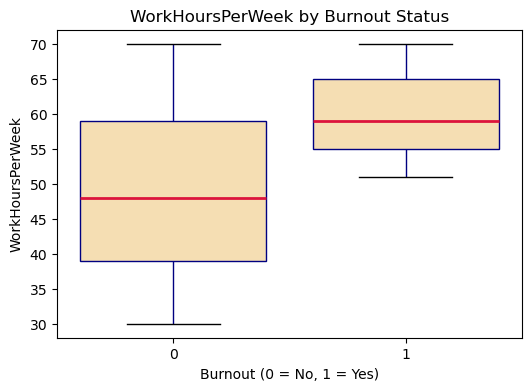

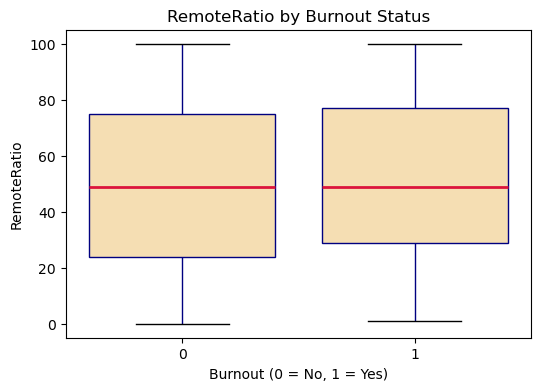

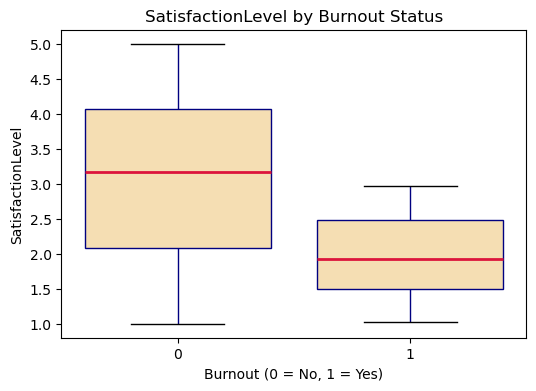

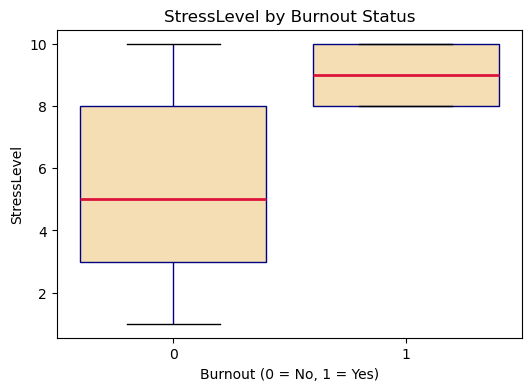

In [71]:
##Gender:The number of male and female employees is nearly equal, a balanced gender representation.
##JobRole:The five job roles have very similar frequencies. No job role is overrepresented.
##Burnout: The majority of employees are classified as No Burnout (0).Only a small proportion belong to the Burnout (1) class, indicating a class imbalance.

numeric_vars = [
    "Age",
    "Experience",
    "WorkHoursPerWeek",
    "RemoteRatio",
    "SatisfactionLevel",
    "StressLevel"
]
for var in numeric_vars:
    plt.figure(figsize=(6,4))
    boxplot_style = {                                            #types of distinguisahable tags for boxplot are explored below
    'boxprops': {'facecolor': 'wheat', 'edgecolor': 'navy'},
    'medianprops': {'color': 'crimson', 'linewidth': 2},
    'whiskerprops': {'color': 'navy'},
    'capprops': {'color': 'black'},
    'flierprops': {'markerfacecolor': 'darkred', 'marker': 'o'}
}

    sns.boxplot(
        x="Burnout",
        y=var,
        data=df,
        color="mediumpurple",
        **boxplot_style
    )

    plt.title(f"{var} by Burnout Status")
    plt.xlabel("Burnout (0 = No, 1 = Yes)")
    plt.ylabel(var)

    plt.show()

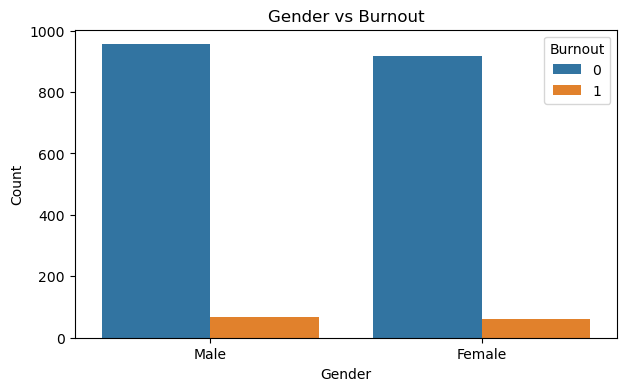

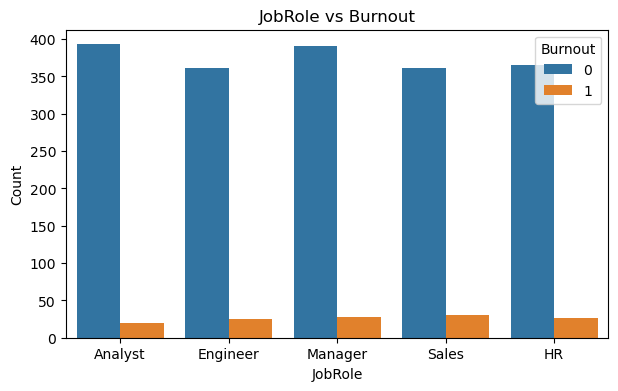

In [72]:
##The minimum and maximum ages are also nearly identical (about 22 to 60 years), indicating that age does not appear to be strongly associated with burnout in this dataset. The median age is approximately 40–41 years in both groups.
##Years of experience do not show a clear relationship with burnout, as both groups have similar experience levels. The median experience is approximately 7–8 years for both groups.
##The entire distribution for the burnout group is shifted toward longer working hours, indicating that working longer hours is strongly associated with burnout.
##The boxplot indicates that the remote work ratio is very similar for employees with and without burnout.
##The boxplot shows a clear negative relationship between job satisfaction and burnout. Employees experiencing burnout (Burnout = 1) have a much lower median satisfaction level (approximately 2) compared to employees without burnout (approximately 3.2)
##The two distributions show very little overlap, indicating that employees with higher stress levels are much more likely to experience burnout.


categoric_vars = ["Gender","JobRole"] # b) Grouped Bar Charts

for var in categoric_vars:
    plt.figure(figsize=(7,4))
    sns.countplot(
        x=var,
        hue="Burnout",
        data=df
    )
    plt.title(f"{var} vs Burnout")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.show()


In [73]:
print("\nGender vs Burnout (%)") # Percentage Tables
gender_table = pd.crosstab(
    df["Gender"],
    df["Burnout"],
    normalize="index"
)*100
print(gender_table.round(2))
print("\nJobRole vs Burnout (%)")
job_table = pd.crosstab(
    df["JobRole"],
    df["Burnout"],
    normalize="index"
)*100
print(job_table.round(2))



Gender vs Burnout (%)
Burnout      0     1
Gender              
Female   93.76  6.24
Male     93.35  6.65

JobRole vs Burnout (%)
Burnout       0     1
JobRole              
Analyst   95.16  4.84
Engineer  93.52  6.48
HR        93.35  6.65
Manager   93.32  6.68
Sales     92.33  7.67


In [74]:
print("\nAverage Numerical Variables by Burnout") # Mean Comparison
print(
df.groupby("Burnout")[
[
"Age",
"Experience",
"WorkHoursPerWeek",
"RemoteRatio",
"SatisfactionLevel",
"StressLevel"
]
].mean()
)


Average Numerical Variables by Burnout
               Age  Experience  WorkHoursPerWeek  RemoteRatio  \
Burnout                                                         
0        40.682523   10.111170         48.886157    49.889898   
1        40.868217    9.542636         59.767442    51.178295   

         SatisfactionLevel  StressLevel  
Burnout                                  
0                 3.065783     5.189204  
1                 1.971938     8.953488  


In [75]:
##StressLevel has the strongest positive correlation with Burnout, indicating that employees with higher stress levels are much more likely to experience burnout.
##SatisfactionLevel has the strongest negative correlation with Burnout, suggesting that employees with lower job satisfaction are more likely to experience burnout.

import seaborn as sns

correlation_matrix = df[numeric_vars].corr()

print("Correlation Matrix")
print(correlation_matrix)

Correlation Matrix
                        Age  Experience  WorkHoursPerWeek  RemoteRatio  \
Age                1.000000    0.640340         -0.015810    -0.030909   
Experience         0.640340    1.000000         -0.019616    -0.042056   
WorkHoursPerWeek  -0.015810   -0.019616          1.000000     0.039890   
RemoteRatio       -0.030909   -0.042056          0.039890     1.000000   
SatisfactionLevel -0.011196   -0.008747          0.026100    -0.056654   
StressLevel       -0.000385   -0.014471         -0.004843     0.013422   

                   SatisfactionLevel  StressLevel  
Age                        -0.011196    -0.000385  
Experience                 -0.008747    -0.014471  
WorkHoursPerWeek            0.026100    -0.004843  
RemoteRatio                -0.056654     0.013422  
SatisfactionLevel           1.000000     0.035406  
StressLevel                 0.035406     1.000000  


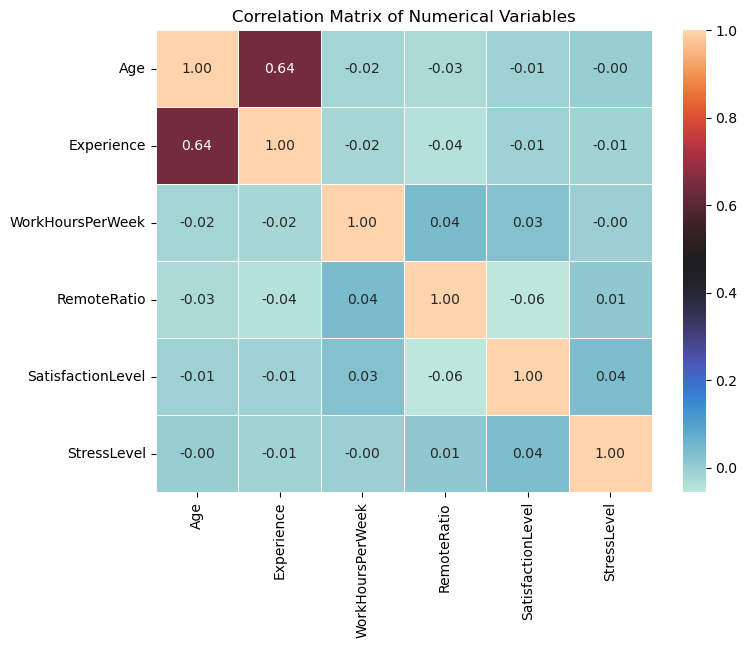

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="icefire",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [77]:
##Employees with higher stress generally report lower job satisfaction, indicating these variables are related but not redundant.no pair of variables appears to have an extremely high correlation (e.g., |r| ≥ 0.8), so there is no evidence of serious multicollinearity. Each numerical variable contributes unique information for understanding employee burnout.

##EDA: The exploratory data analysis revealed several interesting patterns in the employee burnout dataset. Overall, the dataset was in good condition, with no missing values, duplicate records, or data quality issues. Most employee characteristics, such as age, years of experience, and job role, were fairly evenly distributed across the dataset. However, the burnout variable was highly imbalanced, with only about **6.5%** of employees classified as experiencing burnout.
##The analysis showed that **stress level**, **job satisfaction**, and **weekly working hours** were the factors most closely related to burnout. Employees who experienced burnout generally reported much higher stress levels, lower job satisfaction, and worked more hours each week than those who did not experience burnout. These relationships were consistent across the boxplots and the correlation analysis, suggesting that workload and employee well-being play an important role in burnout.
##One finding that stood out was that **age**, **years of experience**, and **remote work ratio** had very little relationship with burnout. Employees of different ages and experience levels appeared equally likely to experience burnout, and working remotely did not seem to make a noticeable difference. Similarly, burnout rates were fairly consistent across genders and job roles, indicating that burnout was not concentrated within a particular group of employees.
##Although these findings provide useful insights, it is important to remember that this is a **synthetic dataset** created for learning purposes. The relationships observed may not accurately represent real employees or workplace environments. As a result, the conclusions should be interpreted with caution and would need to be validated using real-world employee data before being applied in practice.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

X = df.drop(columns=["Burnout", "Name"])
y = df["Burnout"]

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=None,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 1600
Testing samples: 400


In [78]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix",confusion_matrix(y_test, y_pred_log))

Accuracy: 0.96

Confusion Matrix [[370   4]
 [ 12  14]]


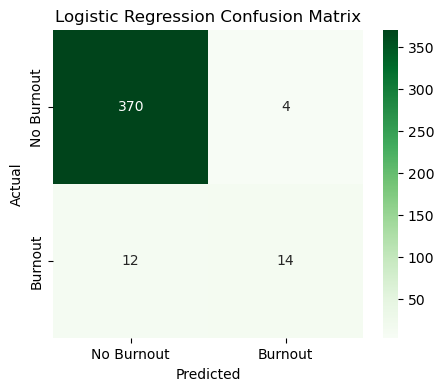

In [79]:

plt.show()
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Burnout","Burnout"],
    yticklabels=["No Burnout","Burnout"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [80]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

# Train model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = model.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Before SMOTE
Burnout
0    1497
1     103
Name: count, dtype: int64

After SMOTE
Burnout
1    1497
0    1497
Name: count, dtype: int64

Accuracy: 0.93

Confusion Matrix
[[346  28]
 [  0  26]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       374
           1       0.48      1.00      0.65        26

    accuracy                           0.93       400
   macro avg       0.74      0.96      0.81       400
weighted avg       0.97      0.93      0.94       400



In [81]:
# Import required metrics from sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
y_pred = model.predict(X_test_scaled)

# Predicted probabilities for ROC-AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Performance after SMOTE")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model Performance after SMOTE
-----------------------------------
Accuracy : 0.9300
Precision: 0.4815
Recall   : 1.0000
F1 Score : 0.6500
ROC-AUC  : 0.9788


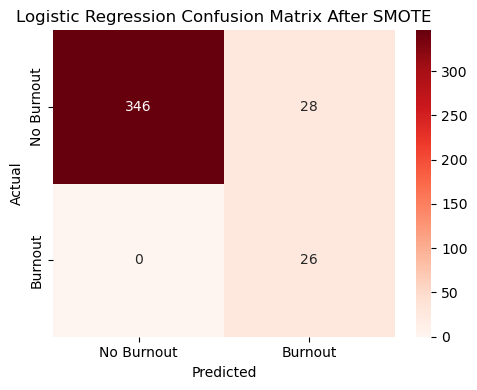

In [82]:
y_true = y_test

# Use scaled X_test, not raw X_test
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(5, 4))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix After SMOTE")
plt.tight_layout()
plt.show()

In [83]:

# Train Decision Tree on SMOTE data since data is severely imbalanced
dt_model = DecisionTreeClassifier(random_state=787)
dt_model.fit(X_train_dt_smote, y_train_dt_smote)

# Predict on original unscaled test data
y_pred_dt_smote = dt_model_smote.predict(X_test)
y_prob_dt_smote = dt_model_smote.predict_proba(X_test)[:, 1]

print("Decision Tree Performance After SMOTE")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt_smote):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt_smote):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt_smote):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dt_smote):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt_smote))

Decision Tree Performance After SMOTE
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix
[[374   0]
 [  0  26]]


In [84]:
print("Depth:", dt_model.get_depth())
print("Leaves:", dt_model.get_n_leaves())

Depth: 3
Leaves: 4


Random Forest Performance After SMOTE
----------------------------------------
Accuracy : 0.9975
Precision: 1.0000
Recall   : 0.9615
F1 Score : 0.9804
ROC-AUC  : 1.0000


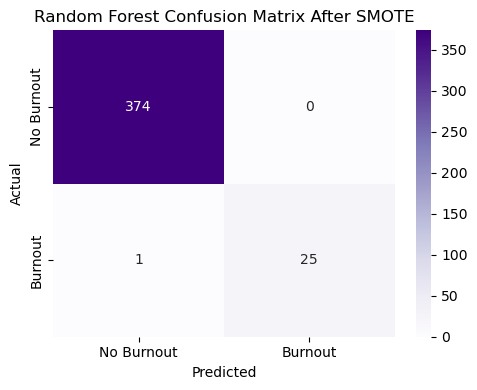

In [85]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42)
X_train_rf_smote, y_train_rf_smote = smote.fit_resample(X_train, y_train)

rf_model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model_smote.fit(X_train_rf_smote, y_train_rf_smote)

y_pred_rf_smote = rf_model_smote.predict(X_test)
y_prob_rf_smote = rf_model_smote.predict_proba(X_test)[:, 1]

cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)

print("Random Forest Performance After SMOTE")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_smote):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf_smote):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf_smote):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf_smote):.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf_smote,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix After SMOTE")
plt.tight_layout()
plt.show()

K-Nearest Neighbors (KNN) Performance
----------------------------------------
Accuracy : 0.9400
Precision: 0.6000
Recall   : 0.2308
F1 Score : 0.3333
ROC-AUC  : 0.9433

Confusion Matrix:
[[370   4]
 [ 20   6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       374
           1       0.60      0.23      0.33        26

    accuracy                           0.94       400
   macro avg       0.77      0.61      0.65       400
weighted avg       0.93      0.94      0.93       400



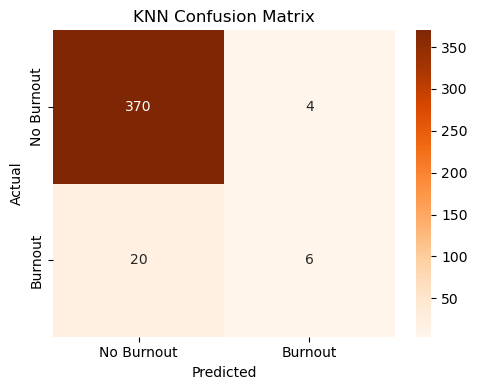

In [86]:

from sklearn.neighbors import KNeighborsClassifier


# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Model performance
print("K-Nearest Neighbors (KNN) Performance")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_knn):.4f}")

print("\nConfusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()


KNN Performance After SMOTE
-----------------------------------
Accuracy : 0.9225
Precision: 0.4545
Recall   : 0.9615
F1 Score : 0.6173
ROC-AUC  : 0.9576

Confusion Matrix:
[[344  30]
 [  1  25]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       374
           1       0.45      0.96      0.62        26

    accuracy                           0.92       400
   macro avg       0.73      0.94      0.79       400
weighted avg       0.96      0.92      0.93       400



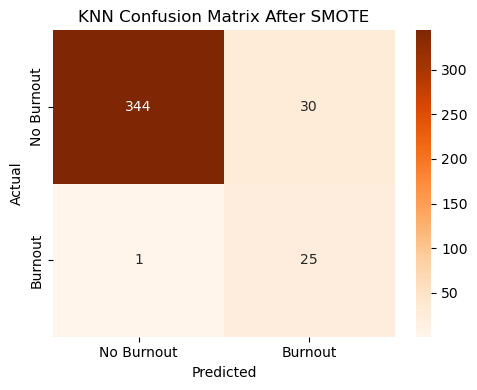

In [87]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_smote, y_train_smote)

# Fixed variable names to match what's used in the evaluation metrics
y_pred_knn_smote = knn_model.predict(X_test_scaled)
y_prob_knn_smote = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\nKNN Performance After SMOTE")
print("-" * 35)
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_smote):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn_smote):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_knn_smote):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_knn_smote):.4f}")

print("\nConfusion Matrix:")
cm_knn_smote = confusion_matrix(y_test, y_pred_knn_smote)
print(cm_knn_smote)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_smote))

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_knn_smote,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix After SMOTE")
plt.tight_layout()
plt.show()

SVM Model Performance
-----------------------------------
Accuracy : 0.9575
Precision: 0.8462
Recall   : 0.4231
F1 Score : 0.5641
ROC-AUC  : 0.9865

Confusion Matrix:
[[372   2]
 [ 15  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       374
           1       0.85      0.42      0.56        26

    accuracy                           0.96       400
   macro avg       0.90      0.71      0.77       400
weighted avg       0.95      0.96      0.95       400



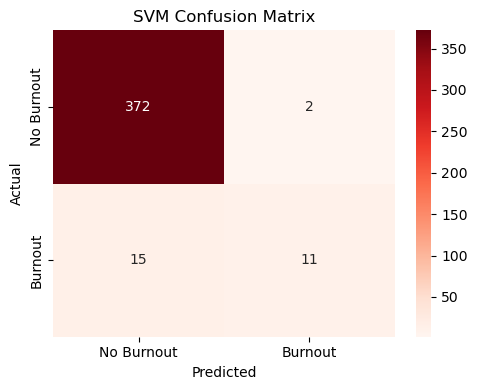

In [88]:
from sklearn.svm import SVC


# SVM model
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("SVM Model Performance")
print("-" * 35)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_svm):.4f}")

print("\nConfusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()


Gradient Boosting Model Performance
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix [[374   0]
 [  0  26]]

Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       374
           1       1.00      1.00      1.00        26

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



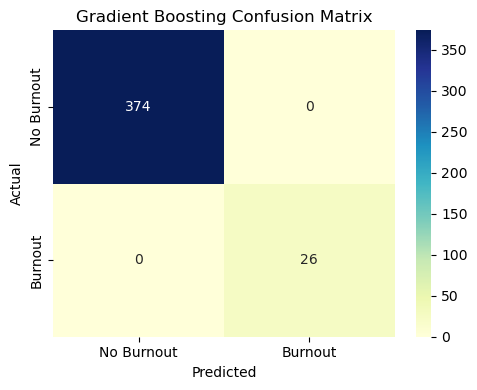

In [89]:
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)     
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Performance metrics
print("Gradient Boosting Model Performance")
print("-" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

print("\nConfusion Matrix",cm_gb)

print("\nClassification Report",classification_report(y_test, y_pred_gb))

# Heatmap
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.tight_layout()
plt.show()

Before SMOTE:
Burnout
0    1497
1     103
Name: count, dtype: int64

After SMOTE:
Burnout
1    1497
0    1497
Name: count, dtype: int64

Gradient Boosting Performance After SMOTE
---------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix:
[[374   0]
 [  0  26]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       374
           1       1.00      1.00      1.00        26

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



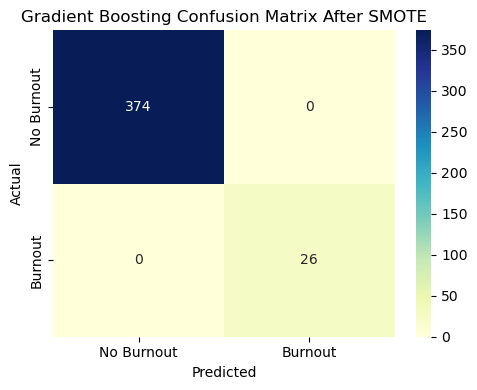

In [90]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Train Gradient Boosting model
gb_model_smote = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_gb_smote = gb_model_smote.predict(X_test)
y_prob_gb_smote = gb_model_smote.predict_proba(X_test)[:, 1]

# Metrics
print("\nGradient Boosting Performance After SMOTE")
print("-" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_smote):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb_smote):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gb_smote):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb_smote):.4f}")

# Confusion Matrix
cm_gb_smote = confusion_matrix(y_test, y_pred_gb_smote)

print("\nConfusion Matrix:")
print(cm_gb_smote)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_smote))

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_gb_smote,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix After SMOTE")
plt.tight_layout()
plt.show()

Naive Bayes Model Performance
-----------------------------------
Accuracy : 0.9700
Precision: 1.0000
Recall   : 0.5385
F1 Score : 0.7000
ROC-AUC  : 0.9980

Confusion Matrix [[374   0]
 [ 12  14]]

Classification Report               precision    recall  f1-score   support

           0       0.97      1.00      0.98       374
           1       1.00      0.54      0.70        26

    accuracy                           0.97       400
   macro avg       0.98      0.77      0.84       400
weighted avg       0.97      0.97      0.97       400



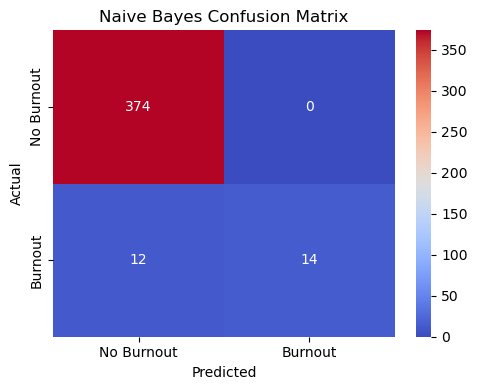

In [91]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Performance metrics
print("Naive Bayes Model Performance")
print("-" * 35)
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_nb):.4f}")

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("\nConfusion Matrix",cm_nb)

print("\nClassification Report",classification_report(y_test, y_pred_nb))

# Heatmap
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.tight_layout()
plt.show()

In [92]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

nb_model_smote = GaussianNB()
nb_model_smote.fit(X_train_smote, y_train_smote)

y_pred_nb_smote = nb_model_smote.predict(X_test)
y_prob_nb_smote = nb_model_smote.predict_proba(X_test)[:, 1]

cm_nb_smote = confusion_matrix(y_test, y_pred_nb_smote)
print(cm_nb_smote)

[[369   5]
 [  5  21]]


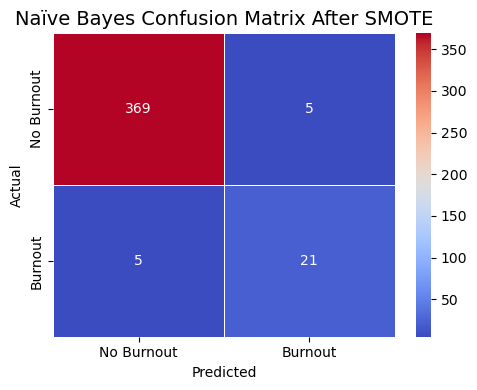

In [93]:
from sklearn.metrics import confusion_matrix  # Import confusion_matrix function
import matplotlib.pyplot as plt  # Import matplotlib for plotting
import seaborn as sns  # Import seaborn for heatmap visualization

# Confusion Matrix
cm_nb_smote = confusion_matrix(y_test, y_pred_nb_smote)

# Plot Heatmap
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb_smote,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    linewidths=0.5,
    xticklabels=['No Burnout', 'Burnout'],
    yticklabels=['No Burnout', 'Burnout']
)

plt.title("Naïve Bayes Confusion Matrix After SMOTE", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier  # Added import for KNN

results = []

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Create and train the missing Decision Tree model
dt_model_before = DecisionTreeClassifier(random_state=42)
dt_model_before.fit(X_train, y_train)

knn_smote = KNeighborsClassifier()  # Added missing KNN + SMOTE model
knn_smote.fit(X_train_smote, y_train_smote)  # Train on SMOTE-balanced data

gb_model_smote = GradientBoostingClassifier(random_state=42)  # Added missing model definition
gb_model_smote.fit(X_train_smote, y_train_smote)  # Train on SMOTE-balanced data

evaluate_model("Logistic Regression", log_model, X_test_scaled, y_test)

evaluate_model("Logistic Regression + SMOTE", model, X_test_scaled, y_test)

evaluate_model("Decision Tree", dt_model_before, X_test, y_test)

evaluate_model("Random Forest", rf_model, X_test, y_test)

evaluate_model("KNN", knn_model, X_test_scaled, y_test)

evaluate_model("KNN + SMOTE", knn_smote, X_test, y_pred)  

evaluate_model("SVM", svm_model, X_test_scaled, y_test)

evaluate_model("Gradient Boosting",gb_model,X_test,y_test)

evaluate_model( "Gradient Boosting + SMOTE",gb_model_smote, X_test, y_test)

evaluate_model("Naive Bayes", nb_model, X_test, y_test)

evaluate_model("Naive Bayes + SMOTE", nb_model_smote, X_test, y_test)

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print(results_df)




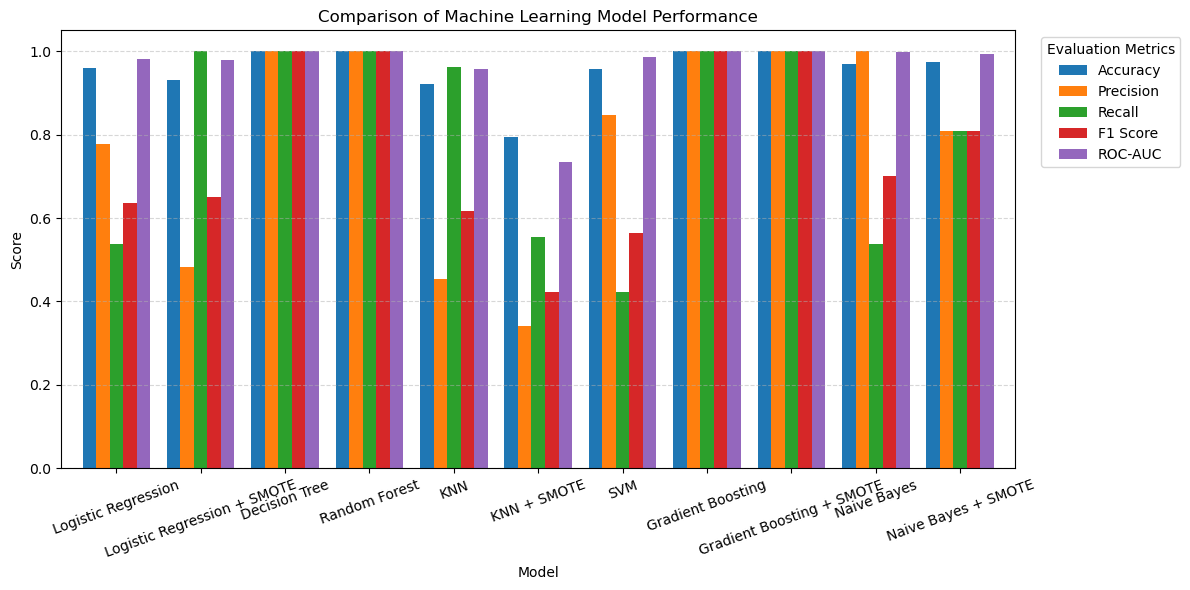

In [95]:
plot_df = results_df.set_index("Model")

ax = plot_df.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8
)

plt.title("Comparison of Machine Learning Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Evaluation Metrics", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()
